# 04 — Results Visualization and Interpretation

This notebook loads the grouped cross-validation results from Notebook 3, creates report-ready figures, summarizes model performance, and interprets the results in the context of porous 45S5 bioactive glass scaffold mechanics.

## 1. Imports and File Paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Visualization imports successful")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

✓ Visualization imports successful
NumPy version: 2.4.6
pandas version: 3.0.3


## 2. Load Saved Results

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

MODEL_RESULTS_PATH = DATA_DIR / "model_comparison.csv"
OOF_PREDICTIONS_PATH = DATA_DIR / "oof_predictions.csv"
FEATURE_IMPORTANCE_PATH = DATA_DIR / "feature_importance.csv"

model_comparison = pd.read_csv(MODEL_RESULTS_PATH)
oof_predictions = pd.read_csv(OOF_PREDICTIONS_PATH)
feature_importance = pd.read_csv(FEATURE_IMPORTANCE_PATH)

print("✓ Saved results loaded successfully")
print(f"Model comparison shape: {model_comparison.shape}")
print(f"OOF predictions shape: {oof_predictions.shape}")
print(f"Feature importance shape: {feature_importance.shape}")
print(f"Figures directory: {FIGURES_DIR}")

✓ Saved results loaded successfully
Model comparison shape: (4, 4)
OOF predictions shape: (256, 4)
Feature importance shape: (22, 2)
Figures directory: /Users/DrewJohnson/Desktop/porous-bioglass-strength-modeling/figures


## 3. Geometry-Inclusive Random Forest Parity Plot

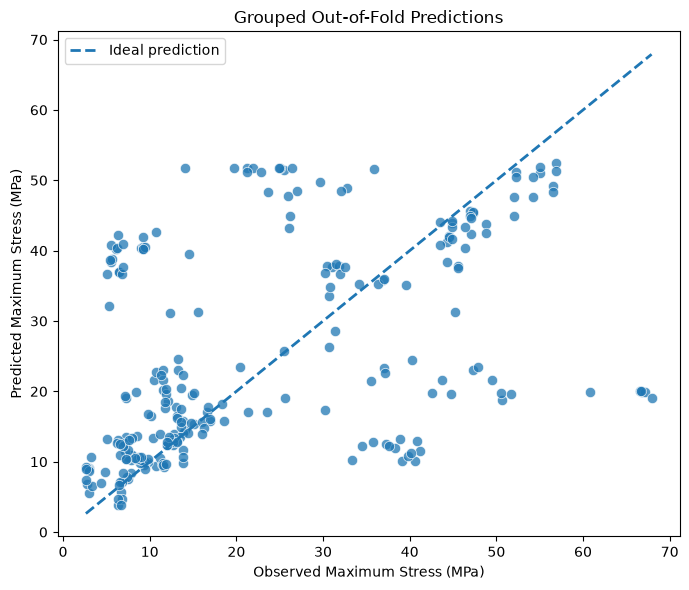

✓ Parity plot saved to: geometry_rf_parity_plot.png


In [3]:
observed = oof_predictions["Observed Maximum Stress (MPa)"]
predicted = oof_predictions["Geometry RF Prediction (MPa)"]

minimum_value = min(observed.min(), predicted.min())
maximum_value = max(observed.max(), predicted.max())

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=observed,
    y=predicted,
    alpha=0.75,
    s=55
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Ideal prediction"
)

plt.title("Grouped Out-of-Fold Predictions")
plt.xlabel("Observed Maximum Stress (MPa)")
plt.ylabel("Predicted Maximum Stress (MPa)")
plt.legend()
plt.tight_layout()

PARITY_FIGURE_PATH = FIGURES_DIR / "geometry_rf_parity_plot.png"
plt.savefig(PARITY_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"✓ Parity plot saved to: {PARITY_FIGURE_PATH.name}")

## 4. Compare Model Performance

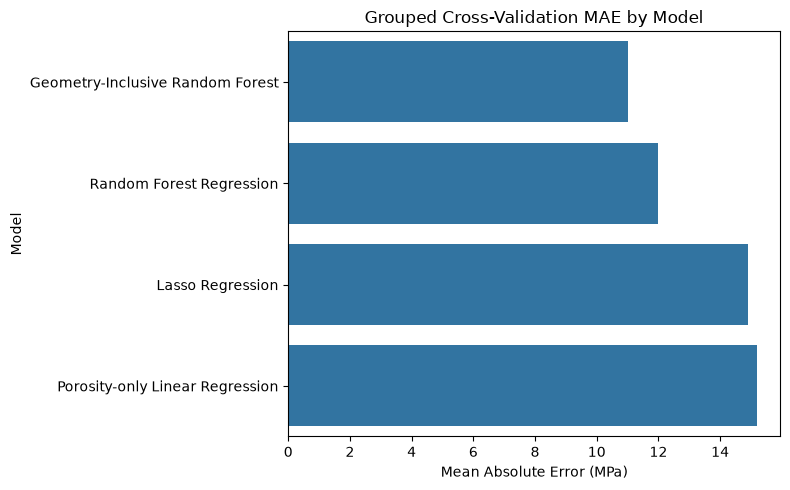

✓ Model comparison figure saved to: model_comparison_mae.png


In [4]:
performance_plot_data = model_comparison.sort_values(
    by="MAE (MPa)",
    ascending=True
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=performance_plot_data,
    x="MAE (MPa)",
    y="Model"
)

plt.title("Grouped Cross-Validation MAE by Model")
plt.xlabel("Mean Absolute Error (MPa)")
plt.ylabel("Model")
plt.tight_layout()

MODEL_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR / "model_comparison_mae.png"
)

plt.savefig(
    MODEL_COMPARISON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Model comparison figure saved to: "
    f"{MODEL_COMPARISON_FIGURE_PATH.name}"
)

## 5. Feature Importance

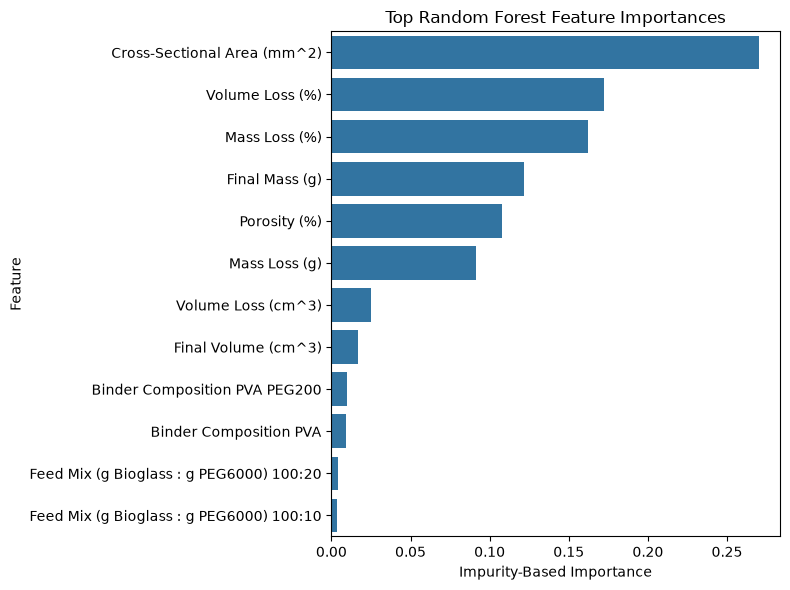

✓ Feature-importance figure saved to: feature_importance.png


In [5]:
top_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(12)
    .copy()
)

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Impurity-Based Importance")
plt.ylabel("Feature")
plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE_PATH = (
    FIGURES_DIR / "feature_importance.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Feature-importance figure saved to: "
    f"{FEATURE_IMPORTANCE_FIGURE_PATH.name}"
)

## 6. Residual Analysis

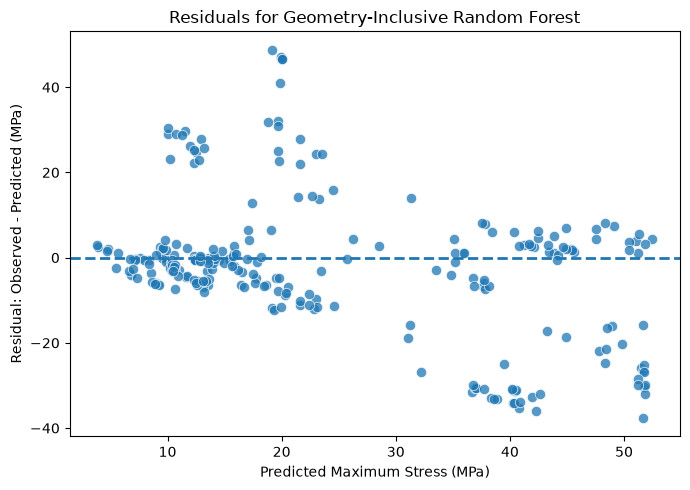

✓ Residual plot saved to: geometry_rf_residual_plot.png


In [6]:
oof_predictions["Residual (MPa)"] = (
    oof_predictions["Observed Maximum Stress (MPa)"]
    - oof_predictions["Geometry RF Prediction (MPa)"]
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=oof_predictions,
    x="Geometry RF Prediction (MPa)",
    y="Residual (MPa)",
    alpha=0.75,
    s=55
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Residuals for Geometry-Inclusive Random Forest")
plt.xlabel("Predicted Maximum Stress (MPa)")
plt.ylabel("Residual: Observed - Predicted (MPa)")
plt.tight_layout()

RESIDUAL_FIGURE_PATH = FIGURES_DIR / "geometry_rf_residual_plot.png"

plt.savefig(
    RESIDUAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Residual plot saved to: {RESIDUAL_FIGURE_PATH.name}")

## 7. Final Results Summary

In [7]:
best_model_row = model_comparison.sort_values(
    by="MAE (MPa)",
    ascending=True
).iloc[0]

geometry_oof_mae = np.mean(
    np.abs(
        oof_predictions["Observed Maximum Stress (MPa)"]
        - oof_predictions["Geometry RF Prediction (MPa)"]
    )
)

geometry_oof_rmse = np.sqrt(
    np.mean(
        (
            oof_predictions["Observed Maximum Stress (MPa)"]
            - oof_predictions["Geometry RF Prediction (MPa)"]
        ) ** 2
    )
)

geometry_oof_r2 = 1 - (
    np.sum(
        (
            oof_predictions["Observed Maximum Stress (MPa)"]
            - oof_predictions["Geometry RF Prediction (MPa)"]
        ) ** 2
    )
    /
    np.sum(
        (
            oof_predictions["Observed Maximum Stress (MPa)"]
            - oof_predictions["Observed Maximum Stress (MPa)"].mean()
        ) ** 2
    )
)

print("Final grouped out-of-fold performance")
print("--------------------------------------")
print(f"Best model by MAE: {best_model_row['Model']}")
print(f"MAE: {geometry_oof_mae:.3f} MPa")
print(f"RMSE: {geometry_oof_rmse:.3f} MPa")
print(f"R²: {geometry_oof_r2:.3f}")

Final grouped out-of-fold performance
--------------------------------------
Best model by MAE: Geometry-Inclusive Random Forest
MAE: 10.969 MPa
RMSE: 16.403 MPa
R²: 0.080


## 8. Notebook Summary

The final results were visualized using grouped out-of-fold predictions so that every plotted prediction came from a model that did not train on that sample's fabrication group.

Key findings:

- The geometry-inclusive random forest had the lowest mean absolute error.
- Grouped out-of-fold performance was MAE = 10.969 MPa, RMSE = 16.403 MPa, and R2 = 0.080.
- The model improved on the porosity-only and Lasso baselines, but overall predictive power remained weak.
- The parity plot showed regression toward the mean, with low-strength samples often overpredicted and high-strength samples often underpredicted.
- Residual clustering indicated that important fabrication or microstructural effects were not fully captured by the available descriptors.
- Cross-sectional area, volume loss, mass loss, final mass, and porosity were among the most influential random forest features.
- Feature importance is model-specific and should not be interpreted as proof of causation.

The main scientific conclusion is that the available descriptors reduce prediction error but do not support robust prediction for unseen fabrication groups.